# **IMPORTS OF PROJECT**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
#adding random seed
torch.manual_seed(42)
np.random.seed(42)

# **LOAD THE DATA**

In [3]:
#Load the data

df = pd.read_csv("/content/ecommerce_inventory_demand.csv")

# Datetime
df['date'] = pd.to_datetime(df['date'])

# Sort
df = df.sort_values(['product_id', 'date'])

# Info
print(df.info())
print(df.describe())

# Nulls
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 6223 entries, 4627 to 4467
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                6223 non-null   datetime64[ns]
 1   product_id          6223 non-null   object        
 2   product_category    6223 non-null   object        
 3   units_sold          5974 non-null   float64       
 4   unit_price          6223 non-null   float64       
 5   stock_on_hand       6223 non-null   int64         
 6   reorder_point       6223 non-null   int64         
 7   is_promotion        6223 non-null   int64         
 8   discount_pct        6223 non-null   float64       
 9   day_of_week         6223 non-null   int64         
 10  month               6223 non-null   int64         
 11  supplier_lead_days  6223 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(6), object(2)
memory usage: 632.0+ KB
None
                       

In [4]:
#Handling missing values using forward fill
# Forward fill within each product
df['units_sold'] = (
    df.groupby('product_id')['units_sold']
      .transform(lambda x: x.ffill().bfill())
)

print(df.isnull().sum())

date                  0
product_id            0
product_category      0
units_sold            0
unit_price            0
stock_on_hand         0
reorder_point         0
is_promotion          0
discount_pct          0
day_of_week           0
month                 0
supplier_lead_days    0
dtype: int64


# VISUALIZATION for units sold and other features

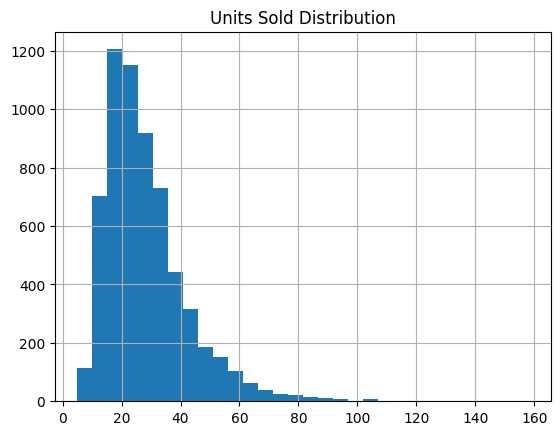

In [5]:
#for units sold

plt.figure()
df['units_sold'].hist(bins=30)
plt.title("Units Sold Distribution")
plt.show()

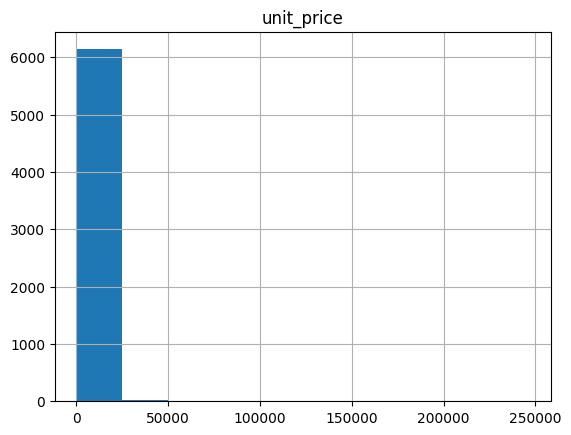

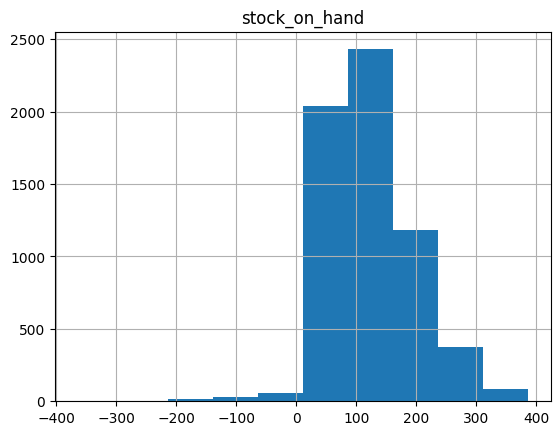

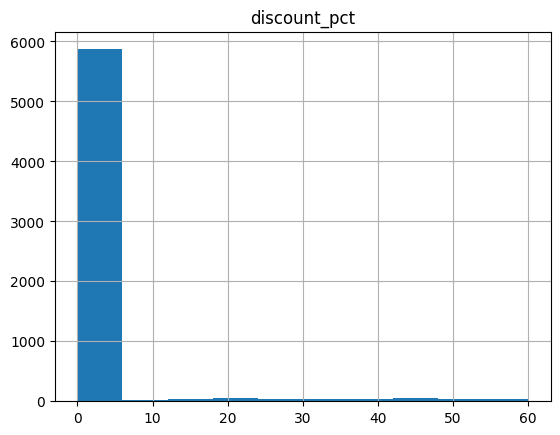

In [6]:
#othe columns
for col in ['unit_price', 'stock_on_hand', 'discount_pct']:
    plt.figure()
    df[col].hist()
    plt.title(col)
    plt.show()

# **Seasonal Decomposition for single product**

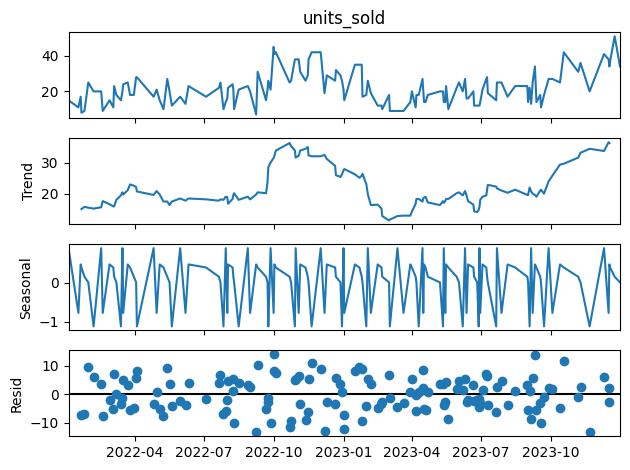

In [7]:
sample = df[df['product_id'] == df['product_id'].iloc[0]]
sample = sample.set_index('date')

result = seasonal_decompose(sample['units_sold'], model='additive', period=7)
result.plot()
plt.show()

# **ACF / PACF**

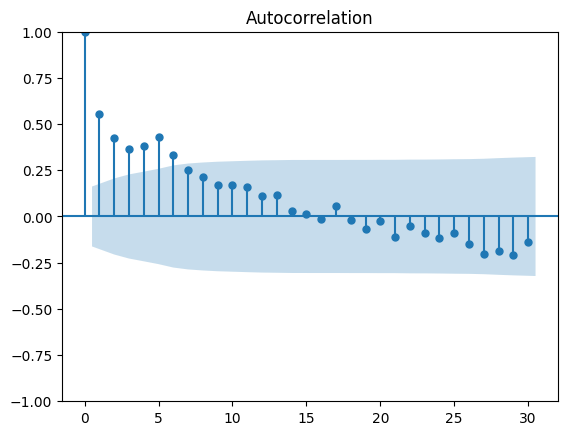

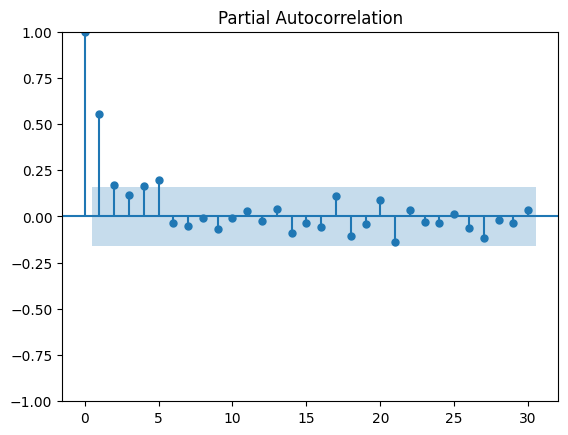

In [8]:
plot_acf(sample['units_sold'], lags=30)
plt.show()

plot_pacf(sample['units_sold'], lags=30)
plt.show()

# **CORRELATION HEATMAP**

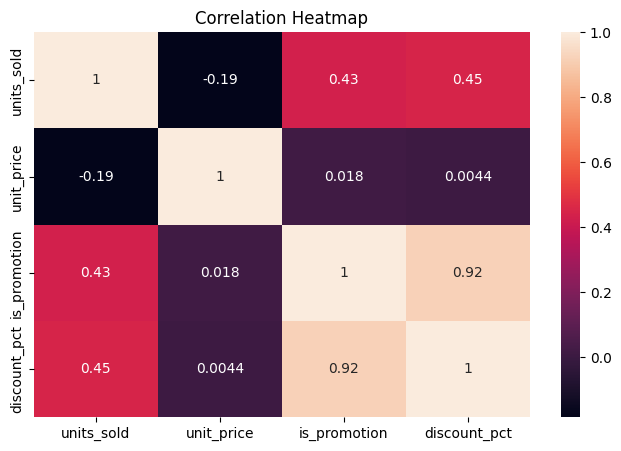

In [9]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['units_sold','unit_price','is_promotion','discount_pct']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# **Outlier Detection using IQR Method**

Remaining outliers:
0
Remaining outliers:
6223


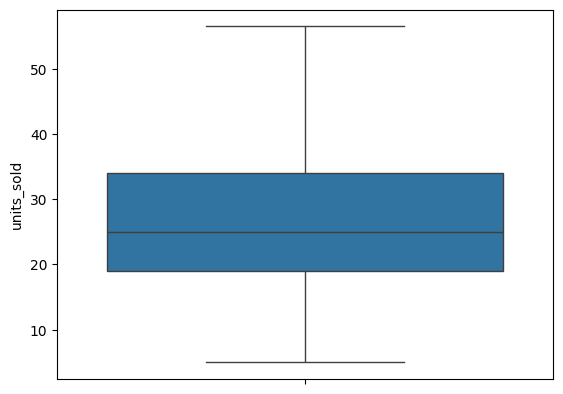

In [10]:
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
              np.where(df[col] > upper, upper, df[col]))


    print("Remaining outliers:")
    print(len(df[(df['unit_price'] > upper)| (df['unit_price'] < lower)]))

# Apply
for col in ['unit_price', 'units_sold']:
    cap_outliers(col)

# Boxplot
sns.boxplot(df['units_sold'])
plt.show()

# **Data Preprocessing**

In [11]:
#Feature Engineering

df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['day_of_week'] = df['date'].dt.dayofweek

df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# Lag features
df['lag_1'] = df.groupby('product_id')['units_sold'].shift(1)
df['lag_7'] = df.groupby('product_id')['units_sold'].shift(7)

# Rolling mean
df['rolling_mean_7'] = df.groupby('product_id')['units_sold'].shift(1).rolling(7).mean()

# Drop new NaNs from feature engineering
df = df.dropna()

In [12]:
#SELECT ONE PRODUCT (or remove filter for all)

product_id = df['product_id'].iloc[0]
data = df[df['product_id'] == product_id]

features = [
    'units_sold', 'unit_price', 'stock_on_hand',
    'is_promotion', 'discount_pct','product_category',
    'day', 'quarter', 'supplier_lead_days', 'month', 'day_of_week',
    'lag_1', 'lag_7', 'rolling_mean_7'
]

data = data[features]

# One-Hot Encoding

In [13]:
df = pd.get_dummies(df, columns=['product_category', 'day_of_week'], drop_first=True)

# **Train-Test and Split**

In [14]:
df = df.sort_values('date')

split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

print(train['date'].min(), train['date'].max())

print(test['date'].min(), test['date'].max())

2022-01-26 00:00:00 2023-08-13 00:00:00
2023-08-13 00:00:00 2023-12-31 00:00:00


# Scaling

In [15]:
scaler = MinMaxScaler()

features = [col for col in df.columns if col not in ['date','product_id']]

train_scaled = scaler.fit_transform(train[features])
test_scaled = scaler.transform(test[features])

# Using Sliding Window

In [16]:
def create_sequences(data, seq_len=10):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len][0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_test, y_test = create_sequences(test_scaled)

# Convert to torch
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(X_train.shape)

print(y_train.shape)

print(X_test.shape)

print(y_test.shape)

torch.Size([4688, 10, 24])
torch.Size([4688])
torch.Size([1165, 10, 24])
torch.Size([1165])


# **LSTM Model**

In [17]:
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 64, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

MLP Baseline

In [18]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

# Training

In [19]:
#Device support
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Move tensors to device
X_train = X_train.to(device)
y_train = y_train.to(device)

X_test = X_test.to(device)
y_test = y_test.to(device)


cpu


# Data Loader

In [20]:
train_dataset = TensorDataset(
    X_train,
    y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False)

Epoch 1, Loss: 0.0356
Epoch 2, Loss: 0.0326
Epoch 3, Loss: 0.0322
Epoch 4, Loss: 0.0322
Epoch 5, Loss: 0.0323
Epoch 6, Loss: 0.0326
Epoch 7, Loss: 0.0329
Epoch 8, Loss: 0.0331
Epoch 9, Loss: 0.0331
Epoch 10, Loss: 0.0330
Best Loss: 0.008371487259864807


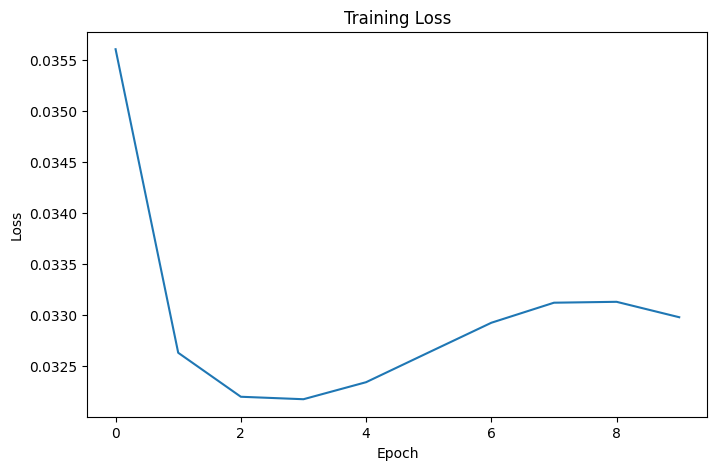

In [24]:
import os

os.makedirs('models', exist_ok=True)

#Training
model = LSTMModel(X_train.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001)
train_losses = []

#Best loss tracking
best_loss = float('inf')

# Training loop
for epoch in range(10):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch).squeeze()
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        #save best model
        if loss.item() < best_loss:
            best_loss = loss.item()
            torch.save(model.state_dict(),'models/lstm_model.pt')
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

print("Best Loss:", best_loss)

#Plotting Loss Curve
plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


# **Prediction**

In [25]:
# Evaluation mode
model.eval()

# Disable gradient calculation
with torch.no_grad():
    y_pred = model(X_test)

# Convert tensor to numpy
y_pred = y_pred.numpy()

# Convert y_test also
y_test_np = y_test.numpy()

# Inverse scaling
y_test_inv = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1,1),
                    np.zeros((len(y_test), X_test.shape[2]-1))], axis=1)
)[:,0]

y_pred_inv = scaler.inverse_transform(
    np.concatenate([y_pred,
                    np.zeros((len(y_pred), X_test.shape[2]-1))], axis=1)
)[:,0]

# **Evaluation**

MAE: 0.21974432468414307
RMSE: 0.28209218452706364


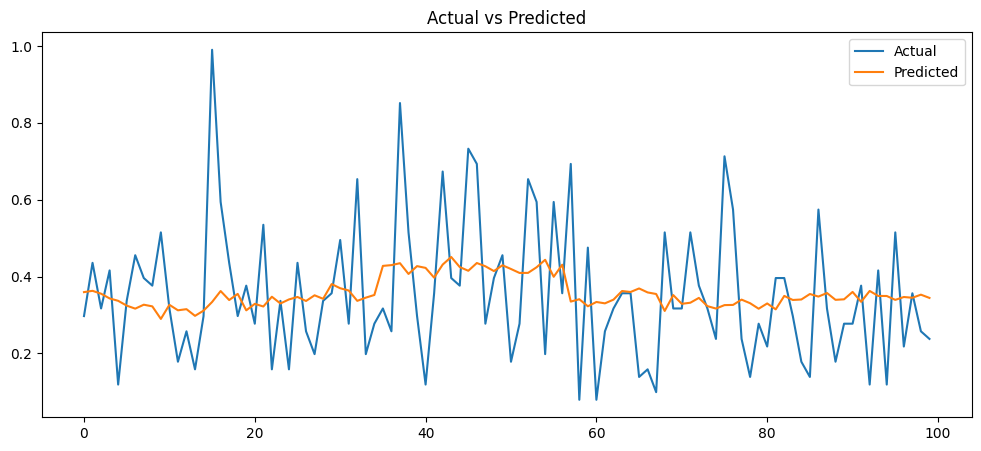

In [26]:
model.eval()
pred = model(X_test).detach().numpy()

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)


plt.figure(figsize=(12,5))
plt.plot(y_test_np[:100],label='Actual')
plt.plot(pred[:100],label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

# **Save Model**

In [27]:
import os
import torch

model_path = 'models/lstm_model.pt'

# Create directory if not exists
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save model
torch.save(model.state_dict(), model_path)

print("✅ Model saved successfully!")

✅ Model saved successfully!


# Pickle Save

In [28]:
import os
import pandas as pd
os.makedirs('models', exist_ok=True)
df.to_pickle('models/Demand cleaned_data.pkl')
df=pd.read_pickle('models/Demand cleaned_data.pkl')     #for read the pickle file
print(df.head())

           date product_id  units_sold  unit_price  stock_on_hand  \
3822 2022-01-26       P038        16.0    12774.65            200   
322  2022-01-27       P033        23.0     9413.85            325   
1578 2022-01-27       P024        12.0     2801.50            208   
802  2022-01-28       P011        13.0     6603.98             75   
837  2022-01-29       P007        21.0    14353.74            146   

      reorder_point  is_promotion  discount_pct  month  supplier_lead_days  \
3822             52             0           0.0      1                   4   
322              74             0           0.0      1                  13   
1578             58             0           0.0      1                   2   
802              27             0           0.0      1                   4   
837              60             0           0.0      1                  14   

      ...  product_category_Beauty  product_category_Electronics  \
3822  ...                    False              

In [30]:
import pickle

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)


#for dataframe
df.to_pickle('models/ Demand cleaned_data.pkl')


In [31]:
#Saving as CSV
df.to_csv('Neural_stock_cleaned_dataset.csv', index=False)
